### First version of social score evolution

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a DataFrame
df = pd.read_excel('FULL ESG DATA 25.03.xlsx', header=[0, 1],
                          skiprows=[2,2],
                            #nrows=10
                            )

# Print the DataFrame
df


Identifier                  Company Name  \
     Unnamed: 0_level_1            Unnamed: 1_level_1   
0                110448  British American Tobacco plc   
1                204386                        CGG SA   
2                225313            Credit Agricole SA   
3                251525              Deutsche Bank AG   
4                251566           Deutsche Telekom AG   
...                 ...                           ...   
1094             94846C                Rizzo Group AB   
1095             65527N              Nokian Tyres plc   
1096             86466Q                 Suedzucker AG   
1097             31529L                  Ferretti SpA   
1098             95074Q                 Wereldhave NV   

     ESG Score Grade\nIn the last 7 FY                                \
                                   FY0 FY-1 FY-2 FY-3 FY-4 FY-5 FY-6   
0                                    A   A+   A+    A    A   A-   A-   
1                                   A-   B+   B+   B+   B+   B+    B   
2                                    B   B+   B+    B   B+    B    B   
3                                    A   A-    A    A   A-   A-   A-   
4                                   A-    A    A   A-   A-   A-   A-   
...                                ...  ...  ...  ...  ...  ...  ...   
1094                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1095                                 B    B    B    B    B    B   C+   
1096                                 B    B    B   B-   C+   C+   C+   
1097                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1098                                B-   B-    B   B-    B    B   B-   

     ESG Combined Score Grade\nIn the last 7 FY  ...  \
                                            FY0  ...   
0                                            C+  ...   
1                                            A-  ...   
2                                            C+  ...   
3                                            C+  ...   
4                                            A-  ...   
...                                         ...  ...   
1094                                        NaN  ...   
1095                                          B  ...   
1096                                          B  ...   
1097                                        NaN  ...   
1098                                         B-  ...   

     ESG Combined Score\nIn the last 7 FY                        \
                                     FY-4       FY-5       FY-6   
0                               88.927167  61.328028  83.040627   
1                               69.567919  68.630067  66.396276   
2                               71.567016  41.135701  44.962708   
3                               41.051302  41.198827  38.818330   
4                               66.479803  76.985986  48.985011   
...                                   ...        ...        ...   
1094                                  NaN        NaN        NaN   
1095                            52.508811  58.782984  47.952315   
1096                            48.211760  44.367919  48.238682   
1097                                  NaN        NaN        NaN   
1098                            64.984199  61.522375  56.925180   

     ESG Controversies Score\nIn the last 7 FY                          \
                                           FY0        FY-1        FY-2   
0                                     4.729730   27.272727   14.473684   
1                                   100.000000  100.000000  100.000000   
2                                    26.699029   91.477273   45.000000   
3                                     2.743902    5.339806    1.704545   
4                                    79.166667   19.512195  100.000000   
...                                        ...         ...         ...   
1094                                       NaN         NaN         NaN   
1095                                 59.166667  100.000000   79.729

In [ ]:
df.columns

MultiIndex([(                                'Identifier', ...),
            (                              'Company Name', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            (         'ESG Score Grade\nIn the last 7 FY', ...),
            ('ESG Combined Score Grade\nIn the last 7 FY', ...),
            ...
            (      'ESG Combined Score\nIn the last 7 FY', ...),
            (      'ESG Combined Score\nIn the last 7 FY', ...),
            (      'ESG Combined Score\nIn the last 7 FY', ...),
            ( 'ESG Controversies Score\nIn the last 7 FY', ...),
            ( 'ESG Controversies Score\nIn the last 7 FY', ...),
         

In [14]:
# Select the columns for 'Social Pillar Score\nIn the last 7 FY'
esg__social_score = df.loc[:, ('Social Pillar Score\nIn the last 7 FY', slice(None))]

# This will give you a DataFrame with the ESG scores for each company over the last 7 financial years
esg__social_score


Social Pillar Score\nIn the last 7 FY                                   \
                                    FY0       FY-1       FY-2       FY-3   
0                             93.480461  93.676962  91.329936  93.269015   
1                             81.231334  75.550208  75.312476  80.926747   
2                             69.815799  74.655532  75.641268  70.785232   
3                             88.784283  85.473866  86.782251  86.242497   
4                             92.035387  92.183666  94.329412  92.507939   
5                             92.866621  92.889404  93.863062  94.002703   
6                             84.460061  85.724179  85.609008  84.975929   
7                             91.074800  91.364761  90.222597  89.054002   
8                             94.076156  94.961569  93.229717  80.431011   
9                             86.010164  84.734621  84.818252  77.839098   

                                    
        FY-4       FY-5       FY-6  
0  89.927850  84.470247  84.434413  
1  76.484152  79.862596  78.439008  
2  74.659777  60.124274  61.289933  
3  82.405085  83.326021  85.922966  
4  90.047769  86.486681  85.771348  
5  85.535649  87.721298  91.338704  
6  82.457169  82.315274  83.437145  
7  82.187595  89.709277  87.516026  
8  75.806687  68.908590  74.722698  
9  80.619058  71.166365  75.049777

In [15]:
import matplotlib.pyplot as plt

# Transpose the DataFrame so that companies are in the columns and years are in the rows
esg_score_transposed = esg__social_score.T
esg_score_transposed


0          1          2  \
Social Pillar Score\nIn the last 7 FY FY0   93.480461  81.231334  69.815799   
                                      FY-1  93.676962  75.550208  74.655532   
                                      FY-2  91.329936  75.312476  75.641268   
                                      FY-3  93.269015  80.926747  70.785232   
                                      FY-4  89.927850  76.484152  74.659777   
                                      FY-5  84.470247  79.862596  60.124274   
                                      FY-6  84.434413  78.439008  61.289933   

                                                    3          4          5  \
Social Pillar Score\nIn the last 7 FY FY0   88.784283  92.035387  92.866621   
                                      FY-1  85.473866  92.183666  92.889404   
                                      FY-2  86.782251  94.329412  93.863062   
                                      FY-3  86.242497  92.507939  94.002703   
                                      FY-4  82.405085  90.047769  85.535649   
                                      FY-5  83.326021  86.486681  87.721298   
                                      FY-6  85.922966  85.771348  91.338704   

                                                    6          7          8  \
Social Pillar Score\nIn the last 7 FY FY0   84.460061  91.074800  94.076156   
                                      FY-1  85.724179  91.364761  94.961569   
                                      FY-2  85.609008  90.222597  93.229717   
                                      FY-3  84.975929  89.054002  80.431011   
                                      FY-4  82.457169  82.187595  75.806687   
                                      FY-5  82.315274  89.709277  68.908590   
                                      FY-6  83.437145  87.516026  74.722698   

                                                    9  
Social Pillar Score\nIn the last 7 FY FY0   86.010164  
                                      FY-1  84.734621  
                                      FY-2  84.818252  
                                      FY-3  77.839098  
                                      FY-4  80.619058  
                                      FY-5  71.166365  
                                      FY-6  75.049777

In [16]:
esg_score_transposed[0]

Social Pillar Score\nIn the last 7 FY  FY0     93.480461
                                       FY-1    93.676962
                                       FY-2    91.329936
                                       FY-3    93.269015
                                       FY-4    89.927850
                                       FY-5    84.470247
                                       FY-6    84.434413
Name: 0, dtype: float64

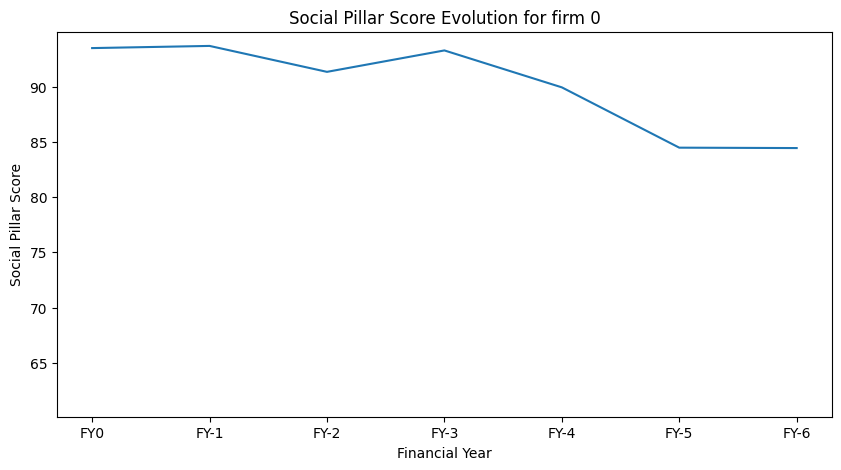

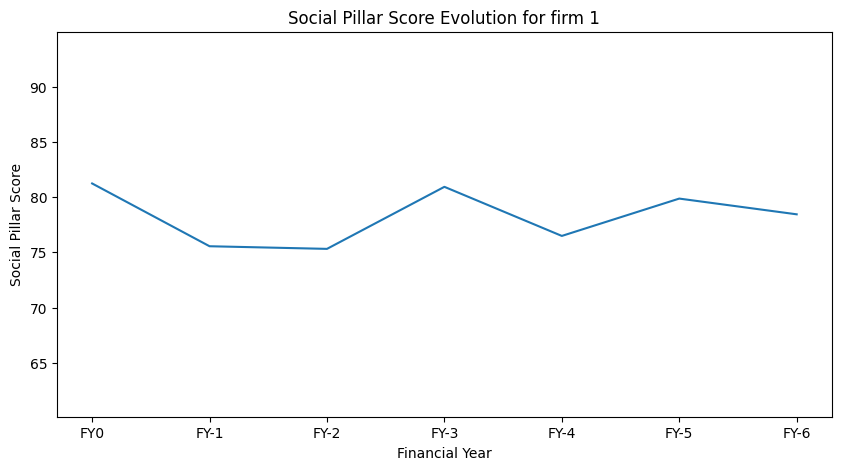

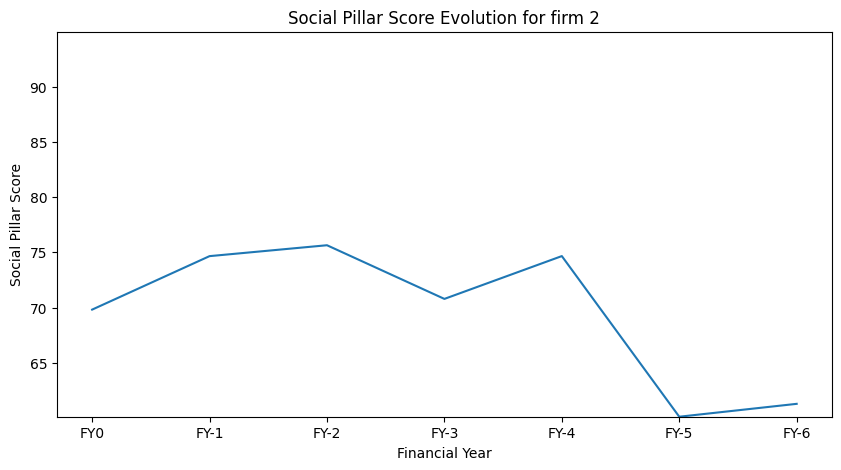

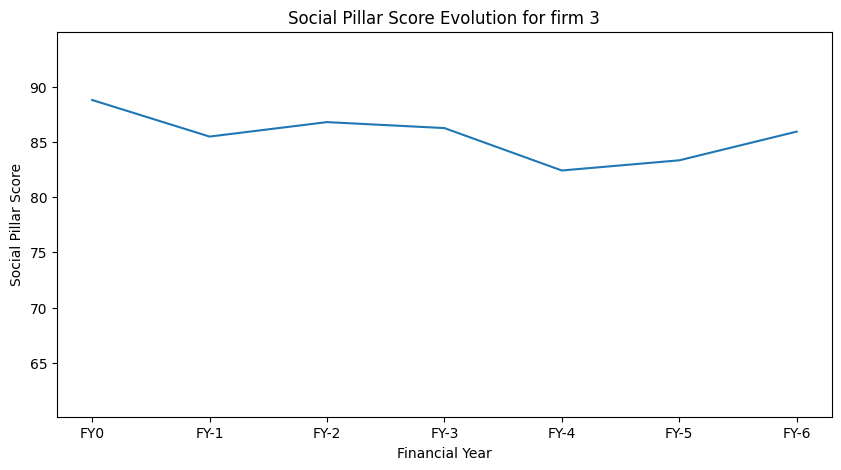

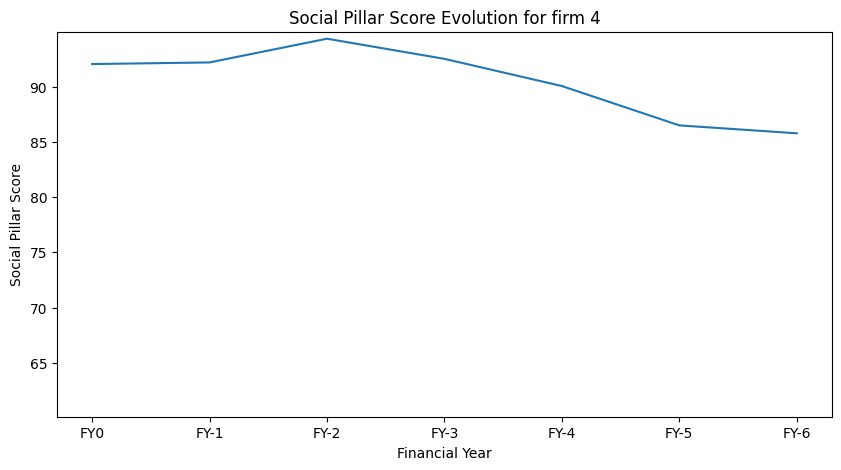

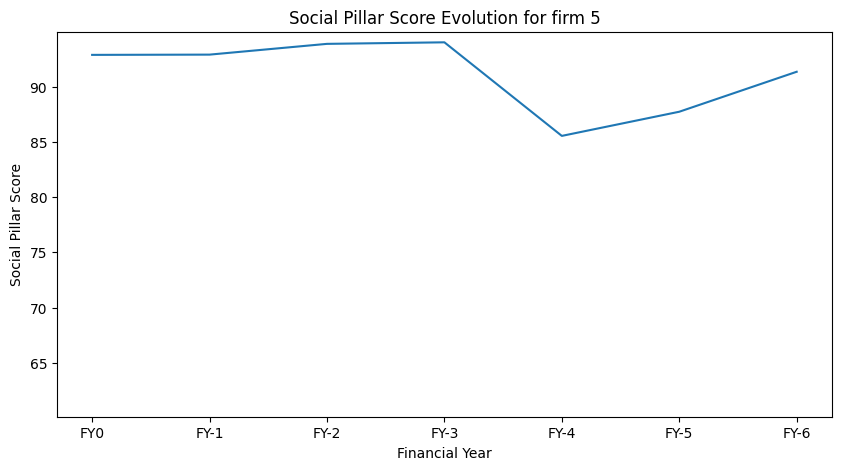

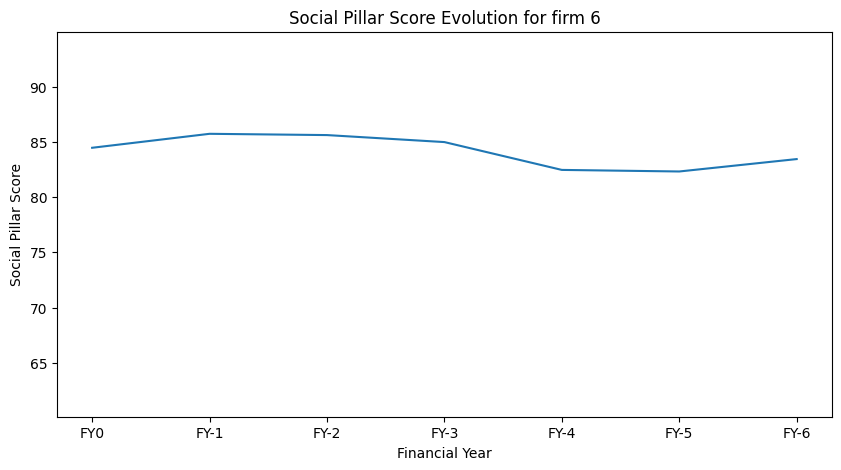

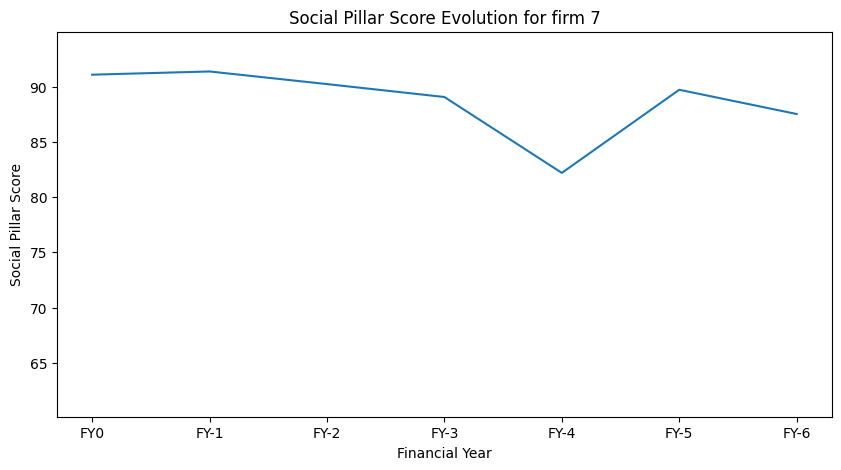

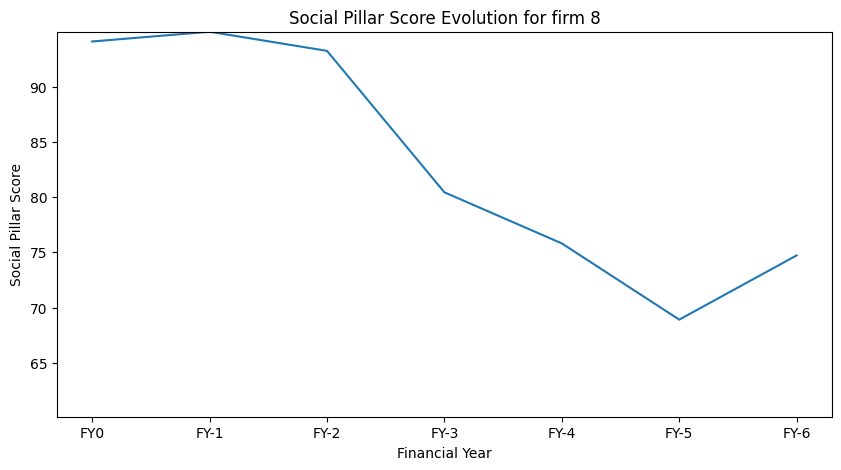

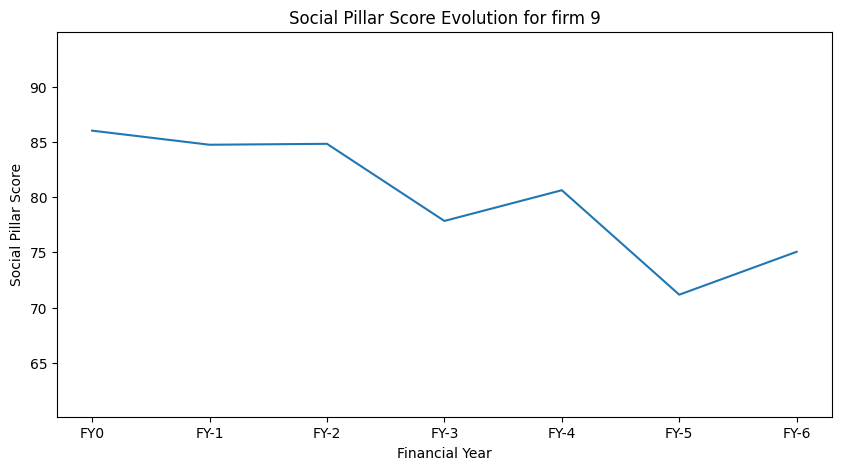

In [22]:
import matplotlib.pyplot as plt

# Find the minimum and maximum values across all columns of the esg_score_transposed DataFrame
min_value = esg_score_transposed.stack().min()
max_value = esg_score_transposed.stack().max()

# Loop through each column of the esg_score_transposed DataFrame
for column_index, column in esg_score_transposed.items():
    # Get the company identifier from the column index
    company_id = column_index

    # Plot the social pillar scores for the company over time
    plt.figure(figsize=(10, 5))
    plt.plot(column.values)
    plt.title(f'Social Pillar Score Evolution for firm {company_id}')
    plt.xlabel('Financial Year')
    plt.ylabel('Social Pillar Score')
    plt.xticks(range(len(column)), column.index.get_level_values(1))  # Get the second level of the index
    plt.ylim(min_value, max_value)  # Set the y-axis limits
    plt.show()


### Done on laptop

### Function to get the social score of a firm or cluster
- need to adapt the code under, currently it plots the evolution of social score grade over time for all firms in the df

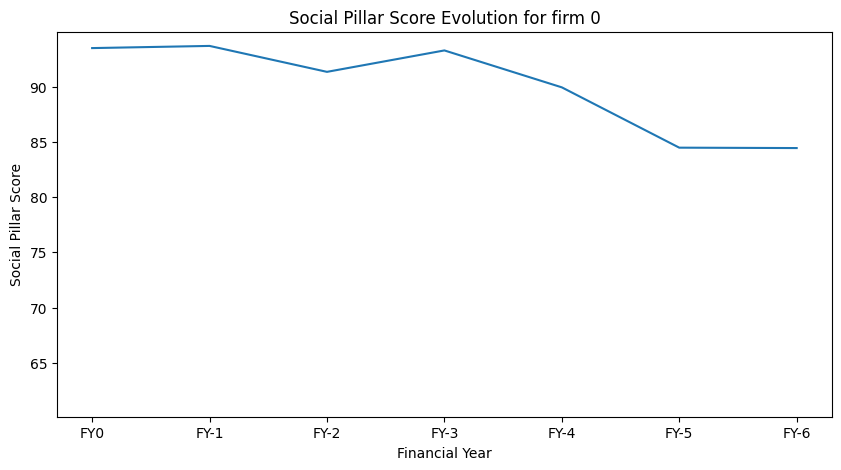

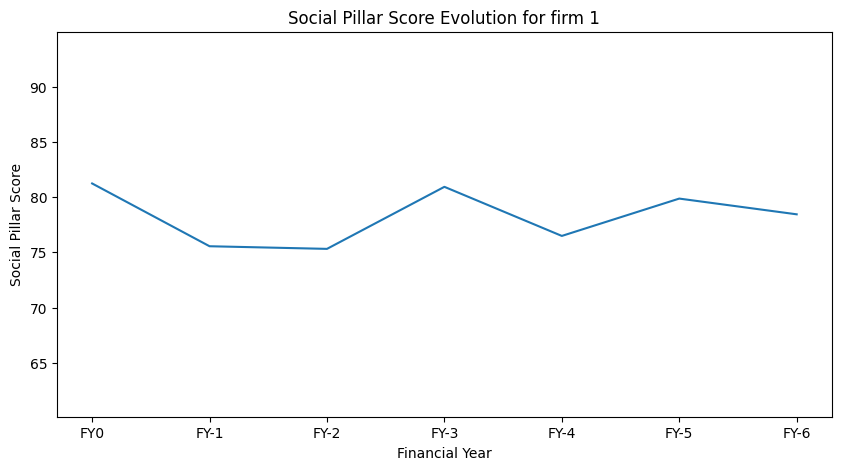

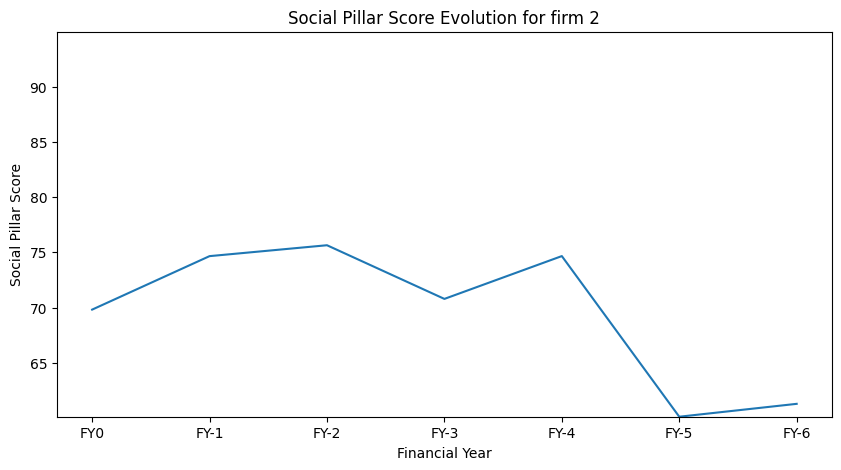

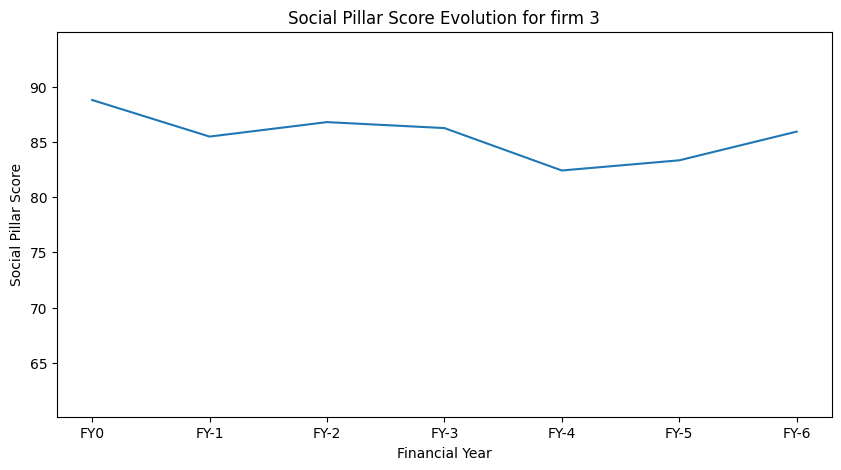

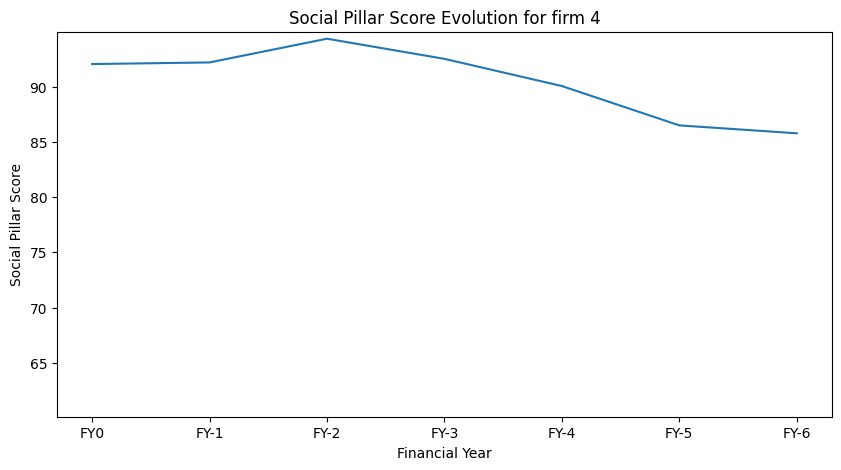

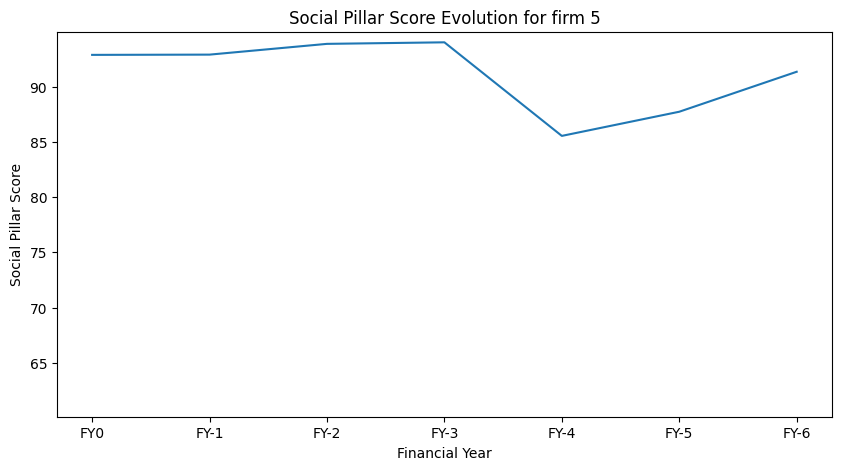

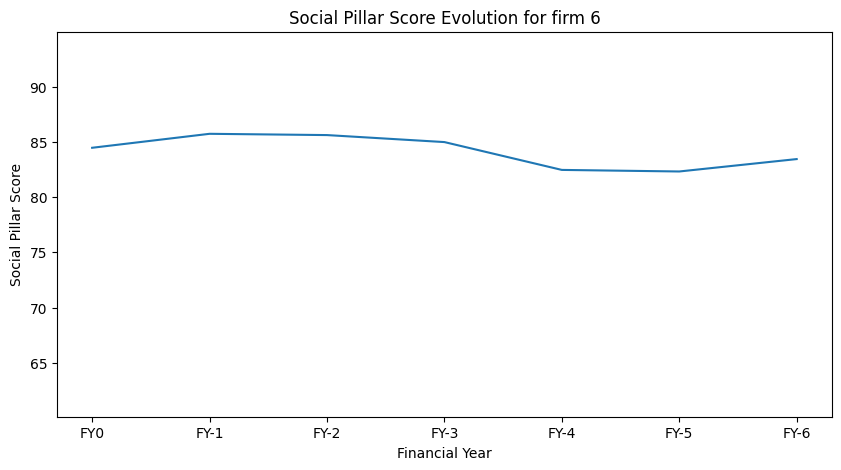

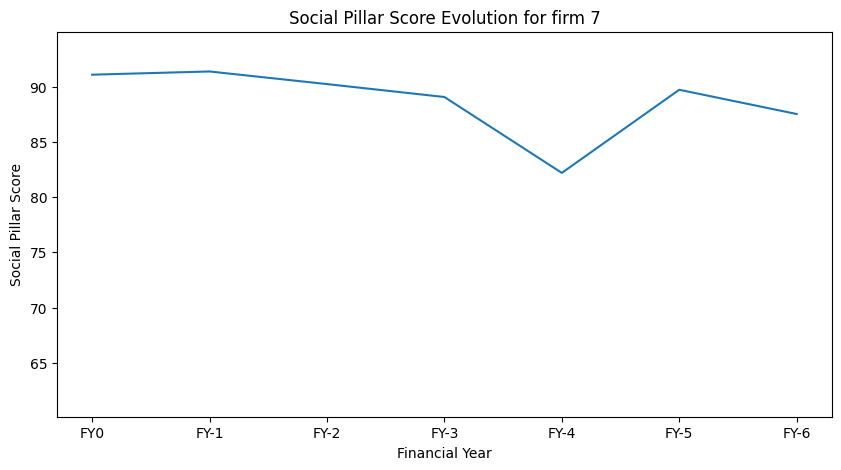

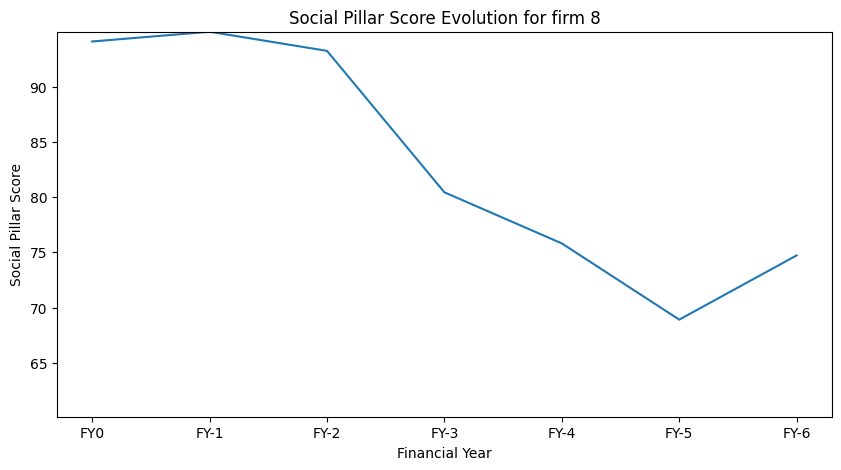

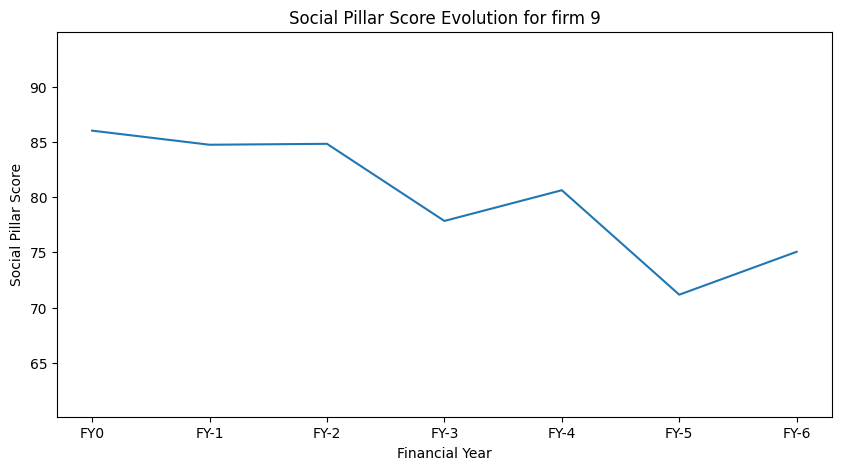

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a DataFrame
df = pd.read_excel('FULL ESG DATA 25.03.xlsx', header=[0, 1],
                          skiprows=[2,2],
                            nrows=10
                            )
df

# Select the columns for 'Social Pillar Score\nIn the last 7 FY'
esg__social_score = df.loc[:, ('Social Pillar Score\nIn the last 7 FY', slice(None))]

# This will give you a DataFrame with the ESG scores for each company over the last 7 financial years
esg__social_score

# Transpose the DataFrame so that companies are in the columns and years are in the rows
esg_score_transposed = esg__social_score.T
esg_score_transposed

esg_score_transposed[0]

# Find the minimum and maximum values across all columns of the esg_score_transposed DataFrame
min_value = esg_score_transposed.stack().min()
max_value = esg_score_transposed.stack().max()

# Loop through each column of the esg_score_transposed DataFrame
for column_index, column in esg_score_transposed.items():
    # Get the company identifier from the column index
    company_id = column_index

    # Plot the social pillar scores for the company over time
    plt.figure(figsize=(10, 5))
    plt.plot(column.values)
    plt.title(f'Social Pillar Score Evolution for firm {company_id}')
    plt.xlabel('Financial Year')
    plt.ylabel('Social Pillar Score')
    plt.xticks(range(len(column)), column.index.get_level_values(1))  # Get the second level of the index
    plt.ylim(min_value, max_value)  # Set the y-axis limits
    plt.show()


### Kmeans testing

#### Version 1 kmeans

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a DataFrame
df = pd.read_excel('FULL ESG DATA 25.03.xlsx', header=[0, 1],
                          skiprows=[2,2],
                            #nrows=150
                            )

# Print the DataFrame
df


Identifier                  Company Name  \
    Unnamed: 0_level_1            Unnamed: 1_level_1   
0               110448  British American Tobacco plc   
1               204386                        CGG SA   
2               225313            Credit Agricole SA   
3               251525              Deutsche Bank AG   
4               251566           Deutsche Telekom AG   
..                 ...                           ...   
145             73161H                      Orlen SA   
146             06680F   Bredband2 i Skandinavien AB   
147             2E6685               Inventionmed SA   
148             G5480U            Liberty Global Ltd   
149             04780P                      Ateme SA   

    ESG Score Grade\nIn the last 7 FY                                \
                                  FY0 FY-1 FY-2 FY-3 FY-4 FY-5 FY-6   
0                                   A   A+   A+    A    A   A-   A-   
1                                  A-   B+   B+   B+   B+   B+    B   
2                                   B   B+   B+    B   B+    B    B   
3                                   A   A-    A    A   A-   A-   A-   
4                                  A-    A    A   A-   A-   A-   A-   
..                                ...  ...  ...  ...  ...  ...  ...   
145                                 B   B-    B   B-    B   B-   B-   
146                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
147                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
148                                B+   B+   B+   B+    B   B+    B   
149                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   

    ESG Combined Score Grade\nIn the last 7 FY  ...  \
                                           FY0  ...   
0                                           C+  ...   
1                                           A-  ...   
2                                           C+  ...   
3                                           C+  ...   
4                                           A-  ...   
..                                         ...  ...   
145                                         B-  ...   
146                                        NaN  ...   
147                                        NaN  ...   
148                                          B  ...   
149                                        NaN  ...   

    ESG Combined Score\nIn the last 7 FY                        \
                                    FY-4       FY-5       FY-6   
0                              88.927167  61.328028  83.040627   
1                              69.567919  68.630067  66.396276   
2                              71.567016  41.135701  44.962708   
3                              41.051302  41.198827  38.818330   
4                              66.479803  76.985986  48.985011   
..                                   ...        ...        ...   
145                            58.542103  57.803107  56.645067   
146                                  NaN        NaN        NaN   
147                                  NaN        NaN        NaN   
148                            34.915051  67.121834  62.058874   
149                                  NaN        NaN        NaN   

    ESG Controversies Score\nIn the last 7 FY                          \
                                          FY0        FY-1        FY-2   
0                                    4.729730   27.272727   14.473684   
1                                  100.000000  100.000000  100.000000   
2                                   26.699029   91.477273   45.000000   
3                                    2.743902    5.339806    1.704545   
4                                   79.166667   19.512195  100.000000   
..                                        ...         ...         ...   
145                                 46.470588   30.188679   25.000000   
146                                       NaN         NaN         NaN   
147                                       NaN         

In [16]:
esg_combined_score = df.loc[:, ('ESG Combined Score\nIn the last 7 FY', slice(None))]
esg_combined_score

ESG Combined Score\nIn the last 7 FY                                   \
                                     FY0       FY-1       FY-2       FY-3   
0                              47.114216  60.763253  53.544785  56.416468   
1                              78.693128  71.452271  74.391600  74.526683   
2                              46.451823  69.487297  58.206679  60.489006   
3                              44.159899  42.845275  42.686293  43.603172   
4                              80.732712  51.778109  86.455326  79.370489   
..                                   ...        ...        ...        ...   
145                            54.120213  43.138900  42.355478  56.768993   
146                                  NaN        NaN        NaN        NaN   
147                                  NaN        NaN        NaN        NaN   
148                            59.366287  69.768980  43.972860  48.298419   
149                                  NaN        NaN        NaN        NaN   

                                      
          FY-4       FY-5       FY-6  
0    88.927167  61.328028  83.040627  
1    69.567919  68.630067  66.396276  
2    71.567016  41.135701  44.962708  
3    41.051302  41.198827  38.818330  
4    66.479803  76.985986  48.985011  
..         ...        ...        ...  
145  58.542103  57.803107  56.645067  
146        NaN        NaN        NaN  
147        NaN        NaN        NaN  
148  34.915051  67.121834  62.058874  
149        NaN        NaN        NaN  

[150 rows x 7 columns]

In [17]:
#esg_combined_score = esg_combined_score.T
esg_combined_score["avg_score"] = None
for index,row in esg_combined_score.iterrows():
    count = row.count()
    if count > 0:
        avg = row.sum()/count
        esg_combined_score.at[index, "avg_score"] = avg
esg_combined_score


C:\Users\Coco\AppData\Local\Temp\ipykernel_11424\4076488001.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esg_combined_score["avg_score"] = None


ESG Combined Score\nIn the last 7 FY                                   \
                                     FY0       FY-1       FY-2       FY-3   
0                              47.114216  60.763253  53.544785  56.416468   
1                              78.693128  71.452271  74.391600  74.526683   
2                              46.451823  69.487297  58.206679  60.489006   
3                              44.159899  42.845275  42.686293  43.603172   
4                              80.732712  51.778109  86.455326  79.370489   
..                                   ...        ...        ...        ...   
145                            54.120213  43.138900  42.355478  56.768993   
146                                  NaN        NaN        NaN        NaN   
147                                  NaN        NaN        NaN        NaN   
148                            59.366287  69.768980  43.972860  48.298419   
149                                  NaN        NaN        NaN        NaN   

                                      avg_score  
          FY-4       FY-5       FY-6             
0    88.927167  61.328028  83.040627  64.447792  
1    69.567919  68.630067  66.396276  71.951135  
2    71.567016  41.135701  44.962708   56.04289  
3    41.051302  41.198827  38.818330  42.051871  
4    66.479803  76.985986  48.985011  70.112491  
..         ...        ...        ...        ...  
145  58.542103  57.803107  56.645067  52.767694  
146        NaN        NaN        NaN       None  
147        NaN        NaN        NaN       None  
148  34.915051  67.121834  62.058874  55.071758  
149        NaN        NaN        NaN       None  

[150 rows x 8 columns]

In [8]:
# Filter dataframe to only include ESG score columns
esg_cols = df.filter(regex='^ESG')

# Calculate number of years of data available for each company
num_years = df.count(axis=1)

# Calculate average score for each company over available years
avg_score = esg_cols.mean(axis=1)

# Calculate weighted average score for each company
weighted_avg_score = (avg_score * num_years / 7).round(2)


TypeError: unsupported operand type(s) for +: 'int' and 'str'

#### Version 2 kmeans

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a DataFrame
df = pd.read_excel('FULL ESG DATA 25.03.xlsx', header=[0, 1],
                          skiprows=[2,2],
                            #nrows=10
                            )

# Print the DataFrame
df


Identifier                  Company Name  \
     Unnamed: 0_level_1            Unnamed: 1_level_1   
0                110448  British American Tobacco plc   
1                204386                        CGG SA   
2                225313            Credit Agricole SA   
3                251525              Deutsche Bank AG   
4                251566           Deutsche Telekom AG   
...                 ...                           ...   
1094             94846C                Rizzo Group AB   
1095             65527N              Nokian Tyres plc   
1096             86466Q                 Suedzucker AG   
1097             31529L                  Ferretti SpA   
1098             95074Q                 Wereldhave NV   

     ESG Score Grade\nIn the last 7 FY                                \
                                   FY0 FY-1 FY-2 FY-3 FY-4 FY-5 FY-6   
0                                    A   A+   A+    A    A   A-   A-   
1                                   A-   B+   B+   B+   B+   B+    B   
2                                    B   B+   B+    B   B+    B    B   
3                                    A   A-    A    A   A-   A-   A-   
4                                   A-    A    A   A-   A-   A-   A-   
...                                ...  ...  ...  ...  ...  ...  ...   
1094                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1095                                 B    B    B    B    B    B   C+   
1096                                 B    B    B   B-   C+   C+   C+   
1097                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1098                                B-   B-    B   B-    B    B   B-   

     ESG Combined Score Grade\nIn the last 7 FY  ...  \
                                            FY0  ...   
0                                            C+  ...   
1                                            A-  ...   
2                                            C+  ...   
3                                            C+  ...   
4                                            A-  ...   
...                                         ...  ...   
1094                                        NaN  ...   
1095                                          B  ...   
1096                                          B  ...   
1097                                        NaN  ...   
1098                                         B-  ...   

     ESG Combined Score\nIn the last 7 FY                        \
                                     FY-4       FY-5       FY-6   
0                               88.927167  61.328028  83.040627   
1                               69.567919  68.630067  66.396276   
2                               71.567016  41.135701  44.962708   
3                               41.051302  41.198827  38.818330   
4                               66.479803  76.985986  48.985011   
...                                   ...        ...        ...   
1094                                  NaN        NaN        NaN   
1095                            52.508811  58.782984  47.952315   
1096                            48.211760  44.367919  48.238682   
1097                                  NaN        NaN        NaN   
1098                            64.984199  61.522375  56.925180   

     ESG Controversies Score\nIn the last 7 FY                          \
                                           FY0        FY-1        FY-2   
0                                     4.729730   27.272727   14.473684   
1                                   100.000000  100.000000  100.000000   
2                                    26.699029   91.477273   45.000000   
3                                     2.743902    5.339806    1.704545   
4                                    79.166667   19.512195  100.000000   
...                                        ...         ...         ...   
1094                                       NaN         NaN         NaN   
1095                                 59.166667  100.000000   79.729

In [13]:
dfs = []
for col_name in df.columns.levels[0]:
    current_df = df.loc[:, (col_name, slice(None))]
    if current_df.dtypes[0] != 'object': # check if the column has numeric data
        current_df['average_score'] = None
        current_df['weight'] = None
        total_years = 0
        for index, row in current_df.iterrows():
            count = row.count()
            if count > 0:
                avg = row.sum() / count
                current_df.at[index, 'average_score'] = avg

            filtered_columns = [col for col in current_df.columns if 'FY' in col[1]]
            available_years = row[filtered_columns].count()
            total_years += available_years

        for index, row in current_df.iterrows():
            filtered_columns = [col for col in current_df.columns if 'FY' in col[1]]
            available_years = row[filtered_columns].count()
            current_df.at[index, 'weight'] = available_years / total_years

        current_df["avg_score_weighted"] = current_df["average_score"] * current_df["weight"]
        dfs.append(current_df)
import random

# randomly select 3 dataframes from the list
selected_dfs = random.sample(dfs, 3)

# print the selected dataframes
for df in selected_dfs:
    df
for df in dfs:
    df.fillna(0, inplace=True)


C:\Users\Coco\AppData\Local\Temp\ipykernel_6488\1316206677.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if current_df.dtypes[0] != 'object': # check if the column has numeric data
C:\Users\Coco\AppData\Local\Temp\ipykernel_6488\1316206677.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_df['average_score'] = None
C:\Users\Coco\AppData\Local\Temp\ipykernel_6488\1316206677.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [16]:
dfs

[     Agrochemical Products Score\nIn the last 7 FY                           \
                                                FY0 FY-1 FY-2 FY-3 FY-4 FY-5   
 0                                              0.0  0.0  0.0  0.0  0.0  0.0   
 1                                              0.0  0.0  0.0  0.0  0.0  0.0   
 2                                              0.0  0.0  0.0  0.0  0.0  0.0   
 3                                              0.0  0.0  0.0  0.0  0.0  0.0   
 4                                              0.0  0.0  0.0  0.0  0.0  0.0   
 ...                                            ...  ...  ...  ...  ...  ...   
 1094                                           0.0  0.0  0.0  0.0  0.0  0.0   
 1095                                           0.0  0.0  0.0  0.0  0.0  0.0   
 1096                                           0.0  0.0  0.0  0.0  0.0  0.0   
 1097                                           0.0  0.0  0.0  0.0  0.0  0.0   
 1098                                   

In [ ]:
for df in dfs:
    

In [18]:
combined_df = pd.concat([df['avg_score_weighted'] for df in dfs], axis=1)
combined_df

,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,...,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000300,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.001069,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.001288,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.001442,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.001474,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.000480,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.001051,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000


In [24]:
kmeans = KMeans(n_clusters=6)
kmeans.fit(combined_df)
labels = kmeans.predict(combined_df)
combined_df['cluster'] = labels

score = silhouette_score(combined_df, labels)
print(score)
combined_df

0.9957219565974265


,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,...,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,cluster
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153,0
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000,0
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514,1
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173,4
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000,0
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836,0
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000,0
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000,0


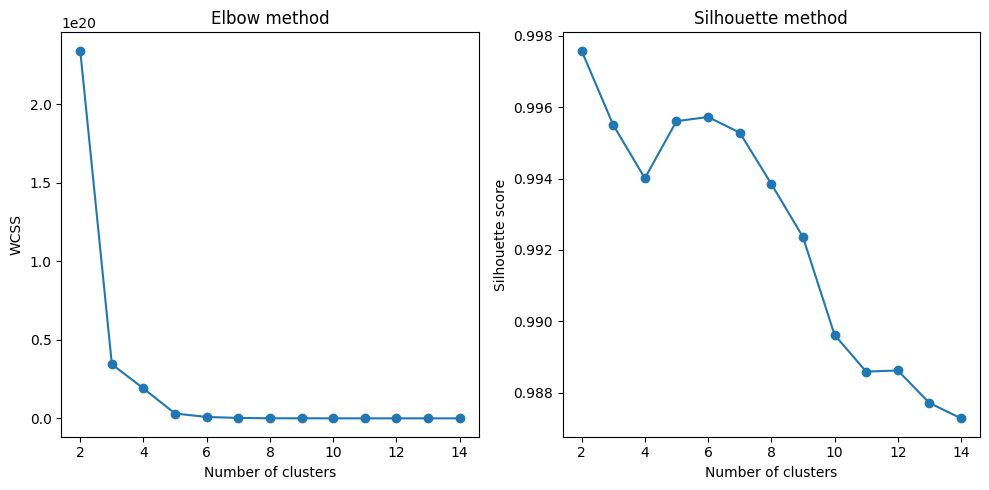

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define the range of cluster numbers to test
num_clusters_range = range(2, 15)

# Create lists to store the WCSS and silhouette scores for each number of clusters
wcss = []
silhouette_scores = []

# Loop through the range of cluster numbers and compute the WCSS and silhouette score for each
for num_clusters in num_clusters_range:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(combined_df)
    labels = kmeans.labels_
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(combined_df, labels))

# Plot the WCSS and silhouette scores
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(num_clusters_range, wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow method')
plt.subplot(1, 2, 2)
plt.plot(num_clusters_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette method')
plt.tight_layout()
plt.show()


In [17]:
combined_df = pd.concat([df['avg_score_weighted'] for df in dfs], axis=1)
combined_df.columns = [df.columns.levels[0][0] for df in dfs]
combined_df

,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,...,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY,Agrochemical Products Score\nIn the last 7 FY
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000300,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.001069,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.001288,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.001442,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.001474,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.000480,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.001051,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000


#### Figure best amount of clusters using silhouette and elbow method

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Rename combined_df to kmeans_data
kmeans_data = combined_df.copy()

# Choose number of clusters to test
num_clusters = range(2, 10)

# Initialize empty lists to store silhouette scores and inertia values
silhouette_scores = []
inertia_values = []

# Loop through number of clusters and perform k-means clustering
for n_clusters in num_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(kmeans_data)
    cluster_labels = kmeans.labels_
    silhouette_score_ = silhouette_score(kmeans_data, cluster_labels)
    silhouette_scores.append(silhouette_score_)
    inertia_values.append(kmeans.inertia_)

# Generate elbow plot to determine optimal number of clusters
plt.figure(figsize=(8,6))
plt.plot(num_clusters, inertia_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.show()

# Print silhouette scores for each number of clusters tested
for i, n_clusters in enumerate(num_clusters):
    print(f'Silhouette score for {n_clusters} clusters: {silhouette_scores[i]:.3f}')


#### Plot distribution of the values / basic stats for each cluster of the different variables that were used

In [ ]:
total_sum = sum(grouped_data.columns)
print(total_sum)

total_sum = sum(grouped_data.columns)
# Calculate the mean value for each variable
mean_values = total_sum / len(grouped_data.columns)
# Calculate the standard deviation for each variable
std_devs = grouped_data.std()
# Create bins for each variable based on the mean value
bins = []
for var in grouped_data.columns:
    bins.append([mean_values[var] - 2*std_devs[var], mean_values[var] - std_devs[var], mean_values[var], mean_values[var] + std_devs[var], mean_values[var] + 2*std_devs[var]])

# Group the data by variable and bin, and count the number of occurrences in each bin
grouped_data = grouped_data.groupby(by=[pd.cut(grouped_data[var], bins=bins[-1]) for var in grouped_data.columns]).size().unstack().fillna(0)

# Plot the distribution of values for each variable
for var in grouped_data.columns:
    plt.hist(grouped_data[var], bins=bins[-1], alpha=0.5, label=var)
    plt.legend(loc='upper right')
    plt.show()

In [36]:
combined_df.columns

Index(['avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 

In [73]:
plot_df = combined_df.copy()
plot_df.drop("cluster", axis=1, inplace=True)
plot_df.columns

Index(['avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 

C:\Users\Coco\AppData\Local\Temp\ipykernel_6488\3037037977.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(data[col_name], data['avg_score_weighted'], c=plt.cm.tab10(i), label=col_name)


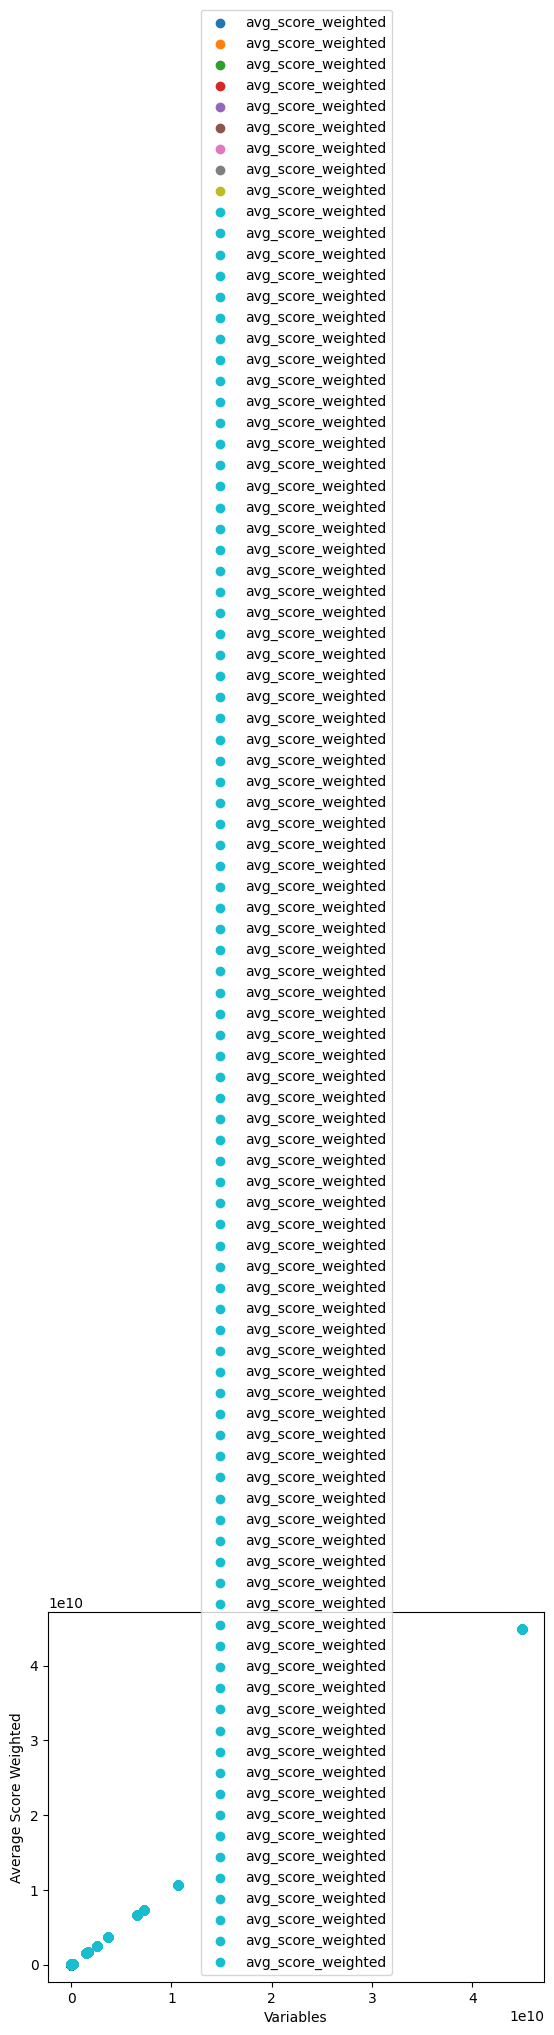

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Iterate through each column in the dataframe, excluding the first column
for i, col_name in enumerate(plot_df.columns[1:]):
    # Filter out rows with missing values
    data = plot_df.dropna(subset=[col_name, 'avg_score_weighted'])

    # Scatter plot of the current column, with color based on the column index
    ax.scatter(data[col_name], data['avg_score_weighted'], c=plt.cm.tab10(i), label=col_name)

# Set axis labels and legend
ax.set_xlabel('Variables')
ax.set_ylabel('Average Score Weighted')
ax.legend()

plt.show()


AttributeError: module 'matplotlib.cm' has no attribute 'tab100'

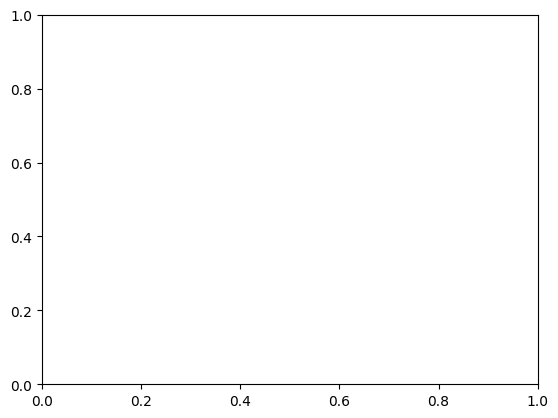

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Iterate through each column in the dataframe, excluding the first column
for i, col_name in enumerate(plot_df.columns[1:]):
    # Filter out rows with missing values
    data = plot_df.dropna(subset=[col_name, 'avg_score_weighted'])

    # Create an array of colors with the same length as the number of data points
    colors = np.full(len(data), plt.cm.tab100(i))

    # Scatter plot of the current column, with color based on the column index
    ax.scatter(data[col_name], data['avg_score_weighted'], c=colors, label=col_name)

# Set axis labels and legend
ax.set_xlabel('Variables')
ax.set_ylabel('Average Score Weighted')
ax.legend()

plt.show()


C:\Users\Coco\AppData\Local\Temp\ipykernel_6488\3874333334.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20c')


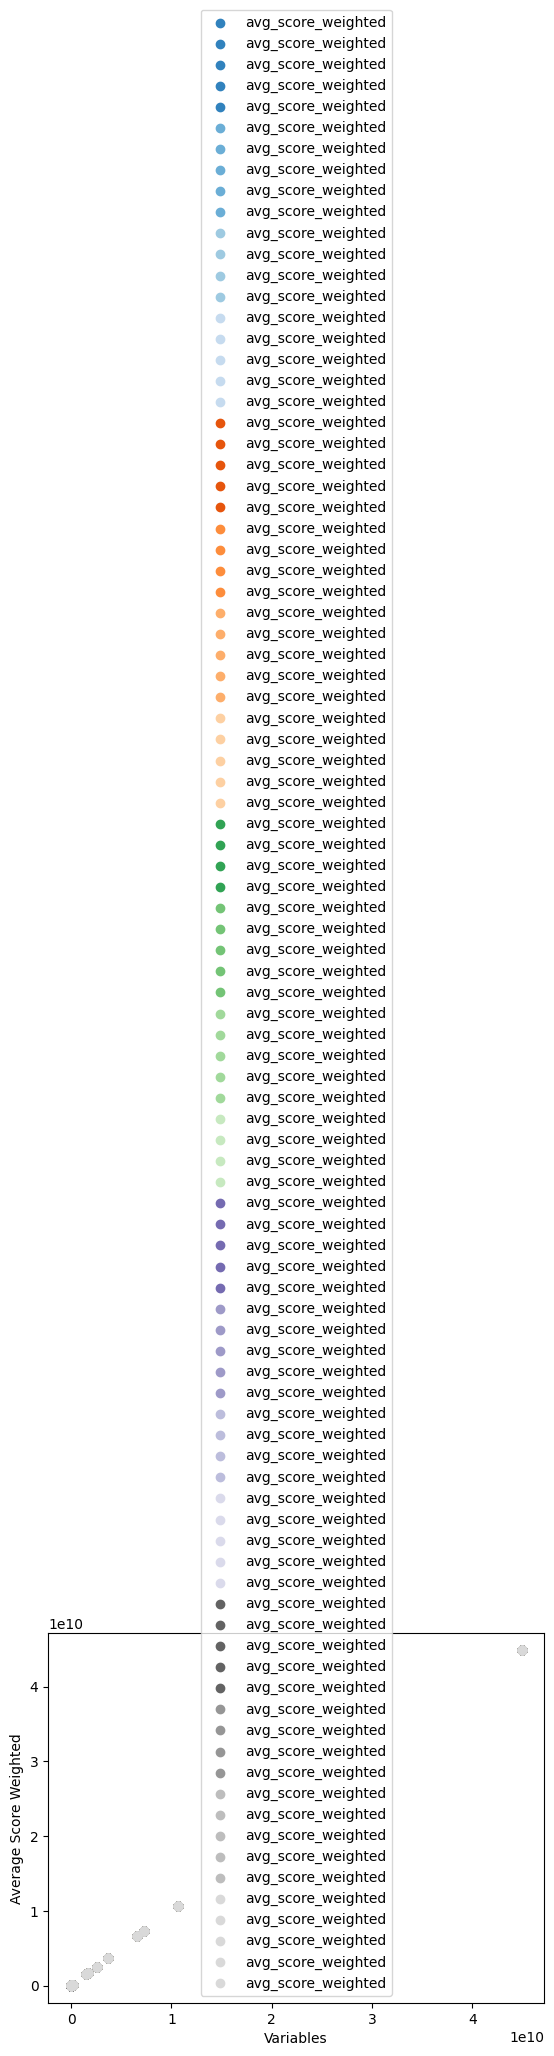

In [56]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots()

# Create a custom colormap with 94 colors
cmap = cm.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, 94)]

# Iterate through each column in the dataframe, excluding the first column
for i, col_name in enumerate(plot_df.columns[:]):
    # Filter out rows with missing values
    #data = plot_df.dropna(subset=[col_name, 'avg_score_weighted'])

    # Scatter plot of the current column, with color based on the column index
    ax.scatter(data[col_name], data['avg_score_weighted'], color=colors[i], label=col_name)

# Set axis labels and legend
ax.set_xlabel('Variables')
ax.set_ylabel('Average Score Weighted')
ax.legend()

plt.show()


In [63]:
plot_df.columns

Index(['avg_score_weighted__0__0', 'avg_score_weighted__1__1',
       'avg_score_weighted__2__2', 'avg_score_weighted__3__3',
       'avg_score_weighted__4__4', 'avg_score_weighted__5__5',
       'avg_score_weighted__6__6', 'avg_score_weighted__7__7',
       'avg_score_weighted__8__8', 'avg_score_weighted__9__9',
       'avg_score_weighted__10__10', 'avg_score_weighted__11__11',
       'avg_score_weighted__12__12', 'avg_score_weighted__13__13',
       'avg_score_weighted__14__14', 'avg_score_weighted__15__15',
       'avg_score_weighted__16__16', 'avg_score_weighted__17__17',
       'avg_score_weighted__18__18', 'avg_score_weighted__19__19',
       'avg_score_weighted__20__20', 'avg_score_weighted__21__21',
       'avg_score_weighted__22__22', 'avg_score_weighted__23__23',
       'avg_score_weighted__24__24', 'avg_score_weighted__25__25',
       'avg_score_weighted__26__26', 'avg_score_weighted__27__27',
       'avg_score_weighted__28__28', 'avg_score_weighted__29__29',
       'avg_sco

In [74]:
plot_df.columns

Index(['avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 'avg_score_weighted',
       'avg_score_weighted', 'avg_score_weighted', 

In [80]:
plot_df.shape

(1099, 94)

In [83]:
plot_df["avg_score_weighted"]

,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,...,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted,avg_score_weighted
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000300,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.001069,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.001288,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.001442,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.001474,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.000480,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.001051,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000


In [84]:
# Iterate over the columns in plot_df
for i, col_name in enumerate(plot_df.columns):
    # Rename the column with a unique identifier
    new_col_name = f"{col_name}_{i}"
    plot_df.rename(columns={col_name: new_col_name}, inplace=True)
plot_df

,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,...,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0,avg_score_weighted_0
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000300,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.001069,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.001288,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.001442,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.001474,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.000480,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.001051,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000


In [79]:
import matplotlib.pyplot as plt

# Filter out rows with missing values
data = plot_df.dropna(subset=['avg_score_weighted'])

# Create a scatter plot of the selected column, with the index as the x-axis
plt.scatter(data.index, data['avg_score_weighted'])
plt.xlabel('Index')
plt.ylabel('Average Score Weighted')
plt.show()


KeyError: 'index'

ValueError: x and y must be the same size

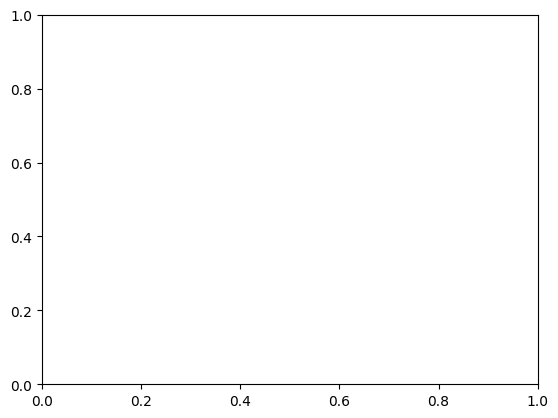

In [77]:
import matplotlib.pyplot as plt

# Select the column to plot
col_name = 'avg_score_weighted'  # Replace with the name of the column you want to plot

# Filter out rows with missing values
#plot_df = plot_df.dropna(subset=[col_name, 'avg_score_weighted'])

# Create the plot
fig, ax = plt.subplots()
ax.scatter(plot_df.index, plot_df[col_name], label=col_name)
ax.set_xlabel('Variables')
ax.set_ylabel('Average Score Weighted')
ax.legend()
plt.show()


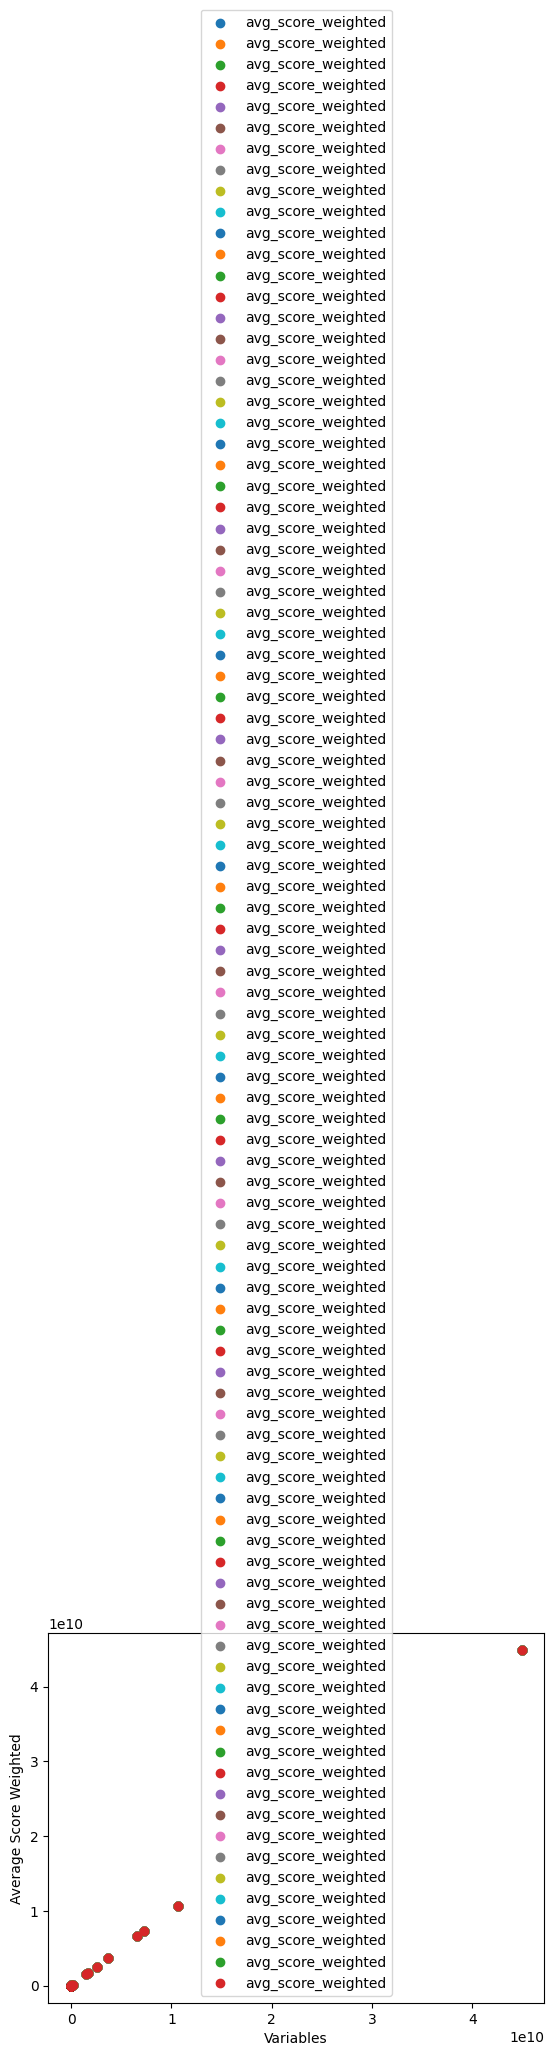

In [59]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots()

# Create a custom colormap with 94 colors
#cmap = cm.get_cmap('tab20c')
#colors = [cmap(i) for i in np.linspace(0, 1, 94)]

# Iterate through each column in the dataframe, excluding the first column
for i, col_name in enumerate(plot_df.columns[:]):
    # Filter out rows with missing values
    #data = plot_df.dropna(subset=[col_name, 'avg_score_weighted'])

    # Scatter plot of the current column, with color based on the column index
    ax.scatter(data[col_name], data['avg_score_weighted'], label=col_name)

# Set axis labels and legend
ax.set_xlabel('Variables')
ax.set_ylabel('Average Score Weighted')
ax.legend()

plt.show()


### Understanding matplotlib

In [3]:
plot_df

NameError: name 'plot_df' is not defined

In [55]:
dfs = []
for col_name in df.columns.levels[0]:
    current_df = df.loc[:, (col_name, slice(None))]
    if current_df.dtypes[0] != 'object': # check if the column has numeric data
        current_df['average_score'] = None
        current_df['weight'] = None
        total_years = 0
        for index, row in current_df.iterrows():
            count = row.count()
            if count > 0:
                avg = row.sum() / count
                current_df.at[index, 'average_score'] = avg

            filtered_columns = [col for col in current_df.columns if 'FY' in col[1]]
            available_years = row[filtered_columns].count()
            total_years += available_years

        for index, row in current_df.iterrows():
            filtered_columns = [col for col in current_df.columns if 'FY' in col[1]]
            available_years = row[filtered_columns].count()
            current_df.at[index, 'weight'] = available_years / total_years

        current_df["avg_score_weighted"] = current_df["average_score"] * current_df["weight"]
        dfs.append(current_df)
import random

# randomly select 3 dataframes from the list
selected_dfs = random.sample(dfs, 3)

# print the selected dataframes

for df in dfs:
    df.fillna(0, inplace=True)
for df in selected_dfs:
    df

C:\Users\Coco\AppData\Local\Temp\ipykernel_15028\2282509193.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if current_df.dtypes[0] != 'object': # check if the column has numeric data
C:\Users\Coco\AppData\Local\Temp\ipykernel_15028\2282509193.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_df['average_score'] = None
C:\Users\Coco\AppData\Local\Temp\ipykernel_15028\2282509193.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

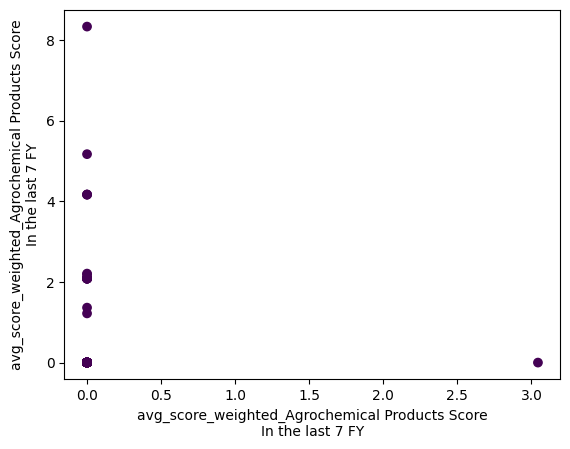

In [15]:
from matplotlib import pyplot as plt
plt.scatter( x= combined_df.iloc[:,0], y= combined_df.iloc[:,1], c= combined_df['cluster'], cmap='viridis')  
plt.xlabel(xlabel=combined_df.columns[0])
plt.ylabel(ylabel=combined_df.columns[1])
plt.show()

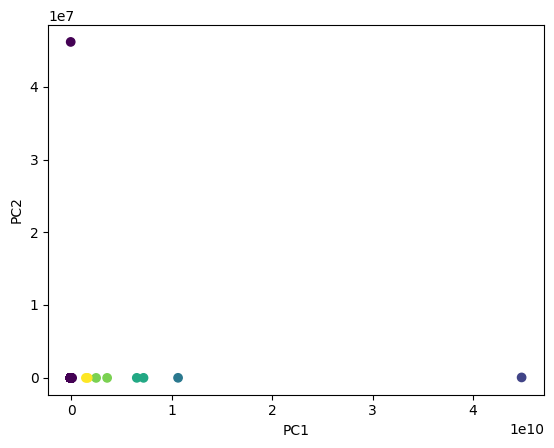

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA to the data and transform it to a lower-dimensional space
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_df.drop('cluster', axis=1))

# Add the cluster labels to the transformed data
pca_result_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_result_df['cluster'] = combined_df['cluster']

# Plot the results using a scatter plot
plt.scatter(pca_result_df['PC1'], pca_result_df['PC2'], c=pca_result_df['cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [78]:
kmeans_df = pd.DataFrame()
for i,df in enumerate(dfs):
    weighted_avg_score = df.xs('avg_score_weighted', level=0, axis=1)
    weighted_avg_score.columns = [f"{df.columns.levels[0][i]}_avg_score_weighted" ]
    kmeans_df = pd.concat([kmeans_df, weighted_avg_score], axis=1)
kmeans_df

,Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted,Animal Testing Score\nIn the last 7 FY_avg_score_weighted,Beta\nIn the last 7 D_avg_score_weighted,Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score Grade\nIn the last 7 FY_avg_score_weighted,Cement CO2 Equivalents Emission Score\nIn the last 7 FY_avg_score_weighted,Cement Energy Use Score\nIn the last 7 FY_avg_score_weighted,Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted,...,Resource Use Score Grade\nIn the last 7 FY_avg_score_weighted,Self-Reported Environmental Fines Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score Grade\nIn the last 7 FY_avg_score_weighted,Social Pillar Score\nIn the last 7 FY_avg_score_weighted,Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted,Staff Transportation Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,Targets Emissions Score\nIn the last 7 FY_avg_score_weighted,Targets Energy Efficiency Score\nIn the last 7 FY_avg_score_weighted
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000300,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.001069,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.001288,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.001442,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.001474,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.000480,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.001051,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000


In [79]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6)
kmeans.fit(kmeans_df)
#labels = kmeans.predict(kmeans_df)
kmeans_df['cluster'] = kmeans.labels_
kmeans_df

,Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted,Animal Testing Score\nIn the last 7 FY_avg_score_weighted,Beta\nIn the last 7 D_avg_score_weighted,Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score Grade\nIn the last 7 FY_avg_score_weighted,Cement CO2 Equivalents Emission Score\nIn the last 7 FY_avg_score_weighted,Cement Energy Use Score\nIn the last 7 FY_avg_score_weighted,Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted,...,Self-Reported Environmental Fines Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score Grade\nIn the last 7 FY_avg_score_weighted,Social Pillar Score\nIn the last 7 FY_avg_score_weighted,Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted,Staff Transportation Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,Targets Emissions Score\nIn the last 7 FY_avg_score_weighted,Targets Energy Efficiency Score\nIn the last 7 FY_avg_score_weighted,cluster
0,0.0,0.0,0,0.209573,0.034433,0.161687,0.0,0.0,0.145294,0.166908,...,0.000000,0.216366,0.0,1.441751,0.0,0.284917,0,0.195039,0.061153,0
1,0.0,0.0,0,0.214891,0.002602,0.083774,0.0,0.0,0.142998,0.111703,...,0.000000,0.050119,0.0,0.000000,0.0,0.081190,0,0.177889,0.000000,0
2,0.0,0.0,0,0.000000,0.023667,0.105547,0.0,0.0,0.172255,0.059009,...,0.000000,0.119507,0.0,0.000000,0.0,0.278274,0,0.179549,0.197514,1
3,0.0,0.0,0,0.000000,0.031774,0.158594,0.0,0.0,0.166699,0.157897,...,0.000000,0.202909,0.0,0.000000,0.0,0.152250,0,0.176297,0.196173,4
4,0.0,0.0,0,0.233006,0.008791,0.158450,0.0,0.0,0.155637,0.173369,...,0.000000,0.000000,0.0,0.000000,0.0,0.202218,0,0.181167,0.159591,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,0.0,0.0,0,0.000000,0.000012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000,0
1095,0.0,0.0,0,0.216619,0.011971,0.147913,0.0,0.0,0.155340,0.086097,...,0.338201,0.218882,0.0,0.000000,0.0,0.010510,0,0.145433,0.207836,0
1096,0.0,0.0,0,0.086078,0.013572,0.099373,0.0,0.0,0.145294,0.097082,...,0.000000,0.157054,0.0,0.000000,0.0,0.061887,0,0.176961,0.000000,0
1097,0.0,0.0,0,0.000000,0.001604,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0,0.000000,0.000000,0


In [80]:
kmeans_df["cluster"].value_counts()

cluster
0    1091
5       2
3       2
2       2
1       1
4       1
Name: count, dtype: int64

In [89]:
kmeans_df["Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted"].value_counts()

KeyError: 'Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted'

In [82]:
kmeans_df["Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted"].value_counts()

Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted
0.000000    1080
1.592577       4
1.662810       2
1.738287       2
1.588611       2
1.139018       1
0.755145       1
1.497836       1
1.154387       1
0.485259       1
0.465319       1
1.569353       1
0.695638       1
1.682806       1
Name: count, dtype: int64

In [85]:
kmeans_df["Social Pillar Score\nIn the last 7 FY_avg_score_weighted"].value_counts()

Social Pillar Score\nIn the last 7 FY_avg_score_weighted
0.000000    1034
0.723894       1
0.472968       1
1.347833       1
0.997870       1
            ... 
0.731433       1
0.138763       1
0.520310       1
0.004855       1
0.149524       1
Name: count, Length: 66, dtype: int64